In [ ]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [1]:
import os
import sys

# ============================================================================
# CONFIGURACIÓN DE DIRECTORIOS
# ============================================================================

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    project_dir = '/content/TFMDS'
    os.chdir(project_dir)
else:
    project_dir = r'C:\Users\jmora\Documents\TFMDS'
    os.chdir(project_dir)

# Agregar el directorio del proyecto al path de Python
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print("Directorio de trabajo:", os.getcwd())
print("Python path incluye proyecto:", project_dir in sys.path)

Directorio de trabajo: C:\Users\jmora\Documents\TFMDS
Python path incluye proyecto: True


## Lectura de fichero y adaptación de los tipos


# CatBoost

- Determinar características utilizar FEATURES
- Descomponer serie en Train y Test
- Características a Normalizar/Estandarizar o codificar
- Crear modelos estimando hiperparámetros
- Valorar modelos




# CatBoost global

In [2]:


import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


In [3]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  lag_ventas_1        625800 non-null  float64       
 12  lag_ventas_2        625800 non-null  fl

In [4]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [5]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'trimestre',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST


In [6]:

# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (CatBoost)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: CATBOOST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")

print("\n🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA CATBOOST
# =====================================================

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50
    }

    model = CatBoostRegressor(**params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=False
    )
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse

# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...")
start_time = time.perf_counter()

study_catboost = optuna.create_study(direction='minimize')
study_catboost.optimize(objective_catboost, n_trials=40, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros CatBoost:")
print(study_catboost.best_params)

best_params = study_catboost.best_params.copy()
best_params.update({
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False
})

best_catboost = CatBoostRegressor(**best_params)

best_catboost.fit(X_train, y_train, verbose=False)

# Predicciones
y_train_pred = best_catboost.predict(X_train)
y_test_pred = best_catboost.predict(X_test)

# Calcular métricas
metricas_train_global = calcular_metricas(y_train, y_train_pred, 'CatBoost Global Train')
metricas_test_global = calcular_metricas(y_test, y_test_pred, 'CatBoost Global Test')

todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_train_global, metricas_test_global])


[I 2025-11-22 21:40:48,780] A new study created in memory with name: no-name-750fa5b6-b36f-4410-b107-35c23914c06e



🔍 MODELO 1: CATBOOST GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)

🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...

🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...


[I 2025-11-22 21:41:02,200] Trial 0 finished with value: 3.8863199720782275 and parameters: {'iterations': 687, 'learning_rate': 0.13639319710013562, 'depth': 9, 'l2_leaf_reg': 1.6763009828399555, 'bagging_temperature': 0.1974917310374833, 'random_strength': 6.9041184729852585, 'border_count': 194, 'min_data_in_leaf': 47}. Best is trial 0 with value: 3.8863199720782275.
[I 2025-11-22 21:41:27,299] Trial 1 finished with value: 3.8994495339927866 and parameters: {'iterations': 689, 'learning_rate': 0.014982691593061087, 'depth': 5, 'l2_leaf_reg': 8.925998256263307, 'bagging_temperature': 0.7315899255443777, 'random_strength': 1.670385243509811, 'border_count': 209, 'min_data_in_leaf': 31}. Best is trial 0 with value: 3.8863199720782275.
[I 2025-11-22 21:41:47,535] Trial 2 finished with value: 3.881580909962614 and parameters: {'iterations': 317, 'learning_rate': 0.03583038160171387, 'depth': 9, 'l2_leaf_reg': 7.833873729199745, 'bagging_temperature': 0.9824664503951664, 'random_strength'

✅ Optuna completado en 876.59 segundos

🏆 Mejores hiperparámetros CatBoost:
{'iterations': 1151, 'learning_rate': 0.070448995883447, 'depth': 9, 'l2_leaf_reg': 6.90484750678481, 'bagging_temperature': 0.5805298929609717, 'random_strength': 7.674755987738204, 'border_count': 33, 'min_data_in_leaf': 16}

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Global Train 1.6118 5.6273 2.3722 0.3093     47.61     139.57 0.6875    93.23
 CatBoost Global Test 1.5713 5.6283 2.3724 0.2655     49.80     144.64 0.7270    96.23

🏆 Mejor modelo: CatBoost Global Train (RMSE: 2.3722)


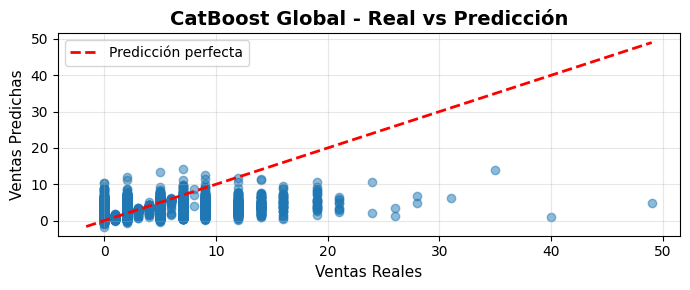

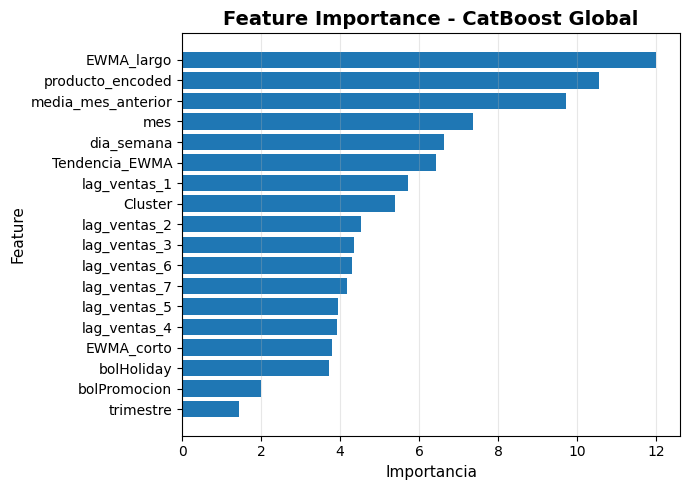

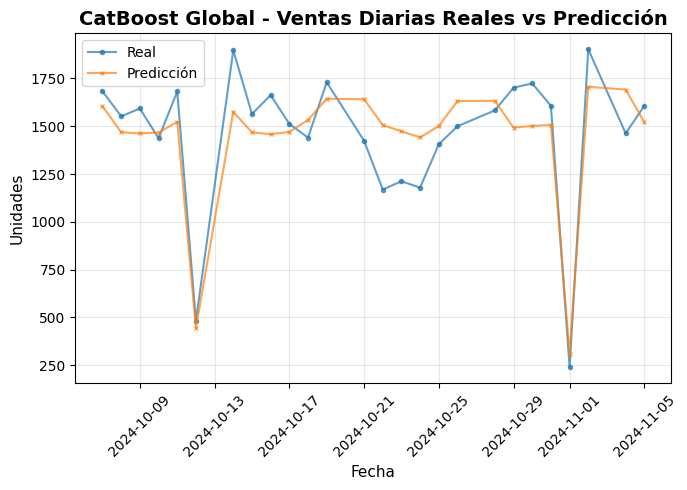

In [7]:

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]

grafico_scatter_prediccion(
    df=df_test_viz,
    col_real=TARGET,
    col_pred='prediccion',
    titulo='CatBoost Global - Real vs Predicción',
    figsize=(7, 3)
)

grafico_feature_importance(
    modelo=best_catboost,
    feature_names=FEATURES,
    top_n=len(FEATURES),
    titulo='Feature Importance - CatBoost Global',
    figsize=(7, 5)
)

# Crear dataframe con suma por día
df_daily = df_test_viz.copy()
df_daily['fecha'] = df_daily['idSecuencia'].dt.date
df_daily_sum = df_daily.groupby('fecha')[[TARGET, 'prediccion']].sum().reset_index()
grafico_real_vs_prediccion(
    df=df_daily_sum,
    col_real=TARGET,
    col_pred='prediccion',
    col_fecha='fecha',
    titulo='CatBoost Global - Ventas Diarias Reales vs Predicción',
    figsize=(7, 5)
)



🔍 MODELO 2: CATBOOST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...
   ✓ MAE: 1.80 | RMSE: 2.54 | R²: 0.1226


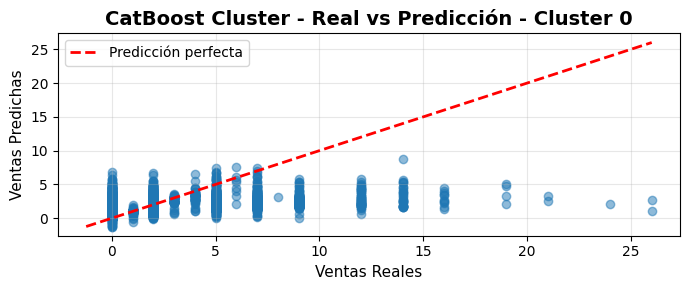

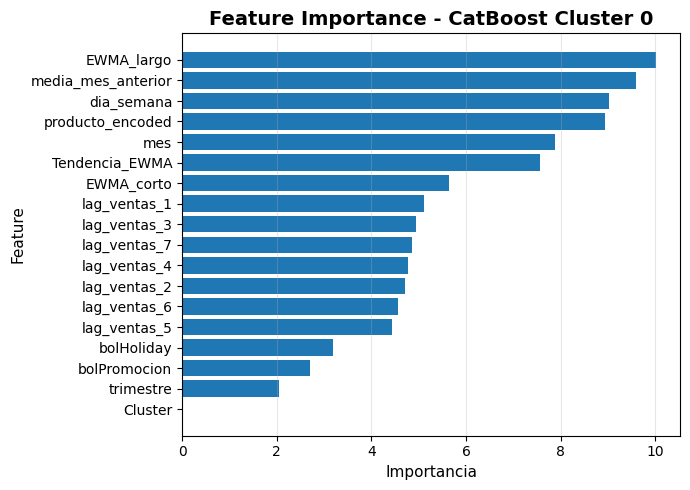

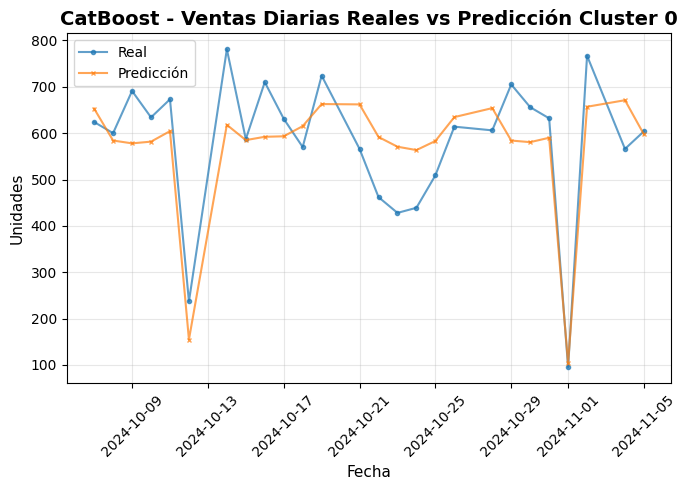


   📌 Producto representativo: 17 (26 registros)
   📊 Estadísticas del error:
      Error medio:             -0.03
      Error abs medio:          1.80
      Error máximo:            24.94


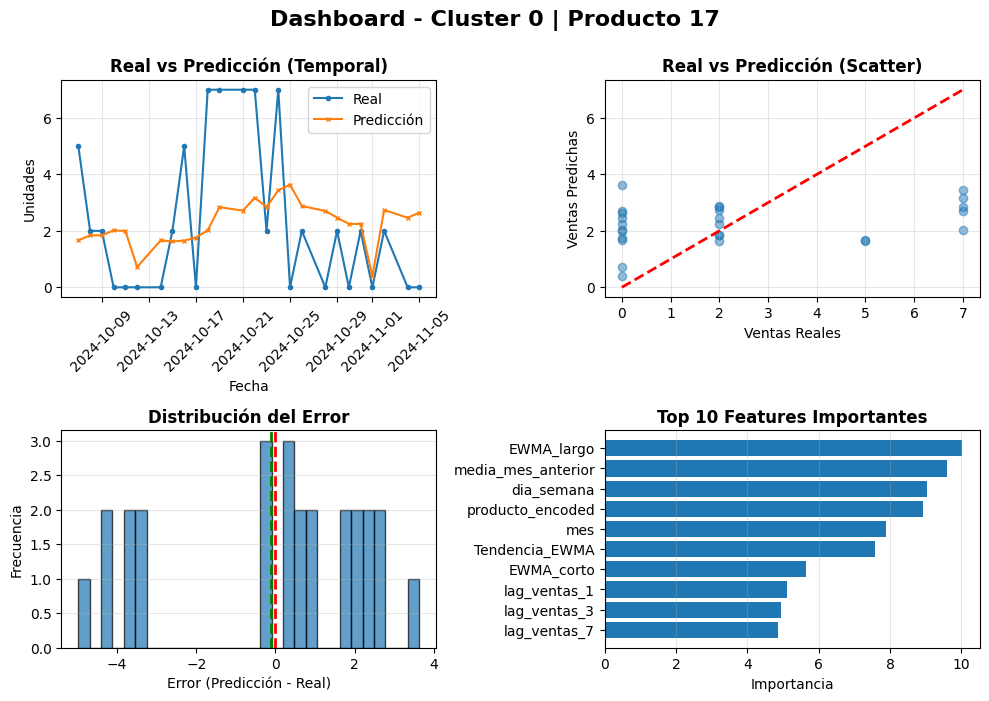


🔄 Entrenando modelo para Cluster 1...
   ✓ MAE: 2.79 | RMSE: 3.62 | R²: 0.1275


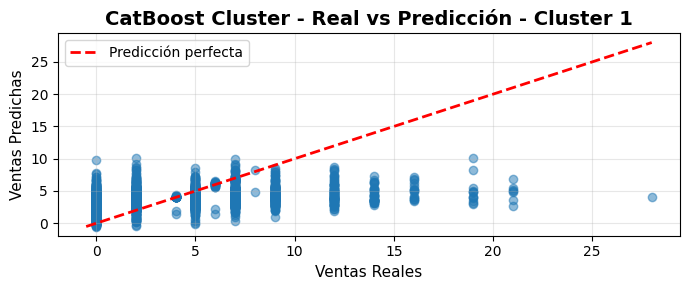

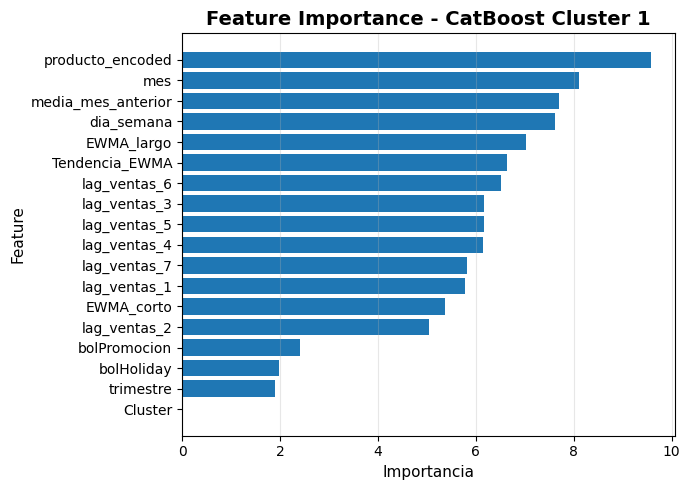

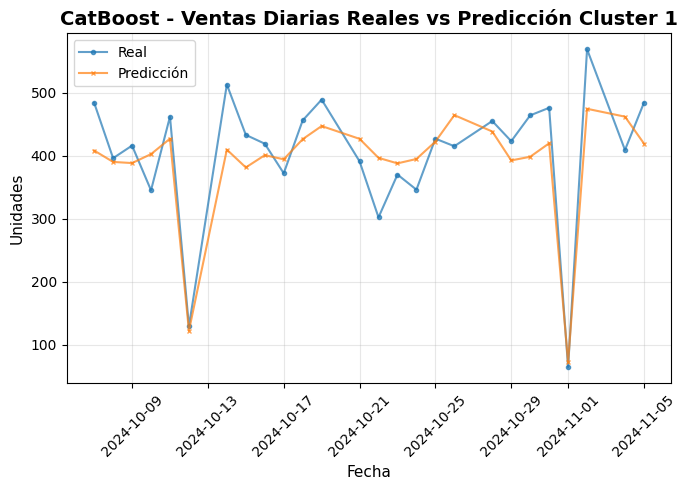


   📌 Producto representativo: 4 (26 registros)
   📊 Estadísticas del error:
      Error medio:             -0.12
      Error abs medio:          2.79
      Error máximo:            23.87


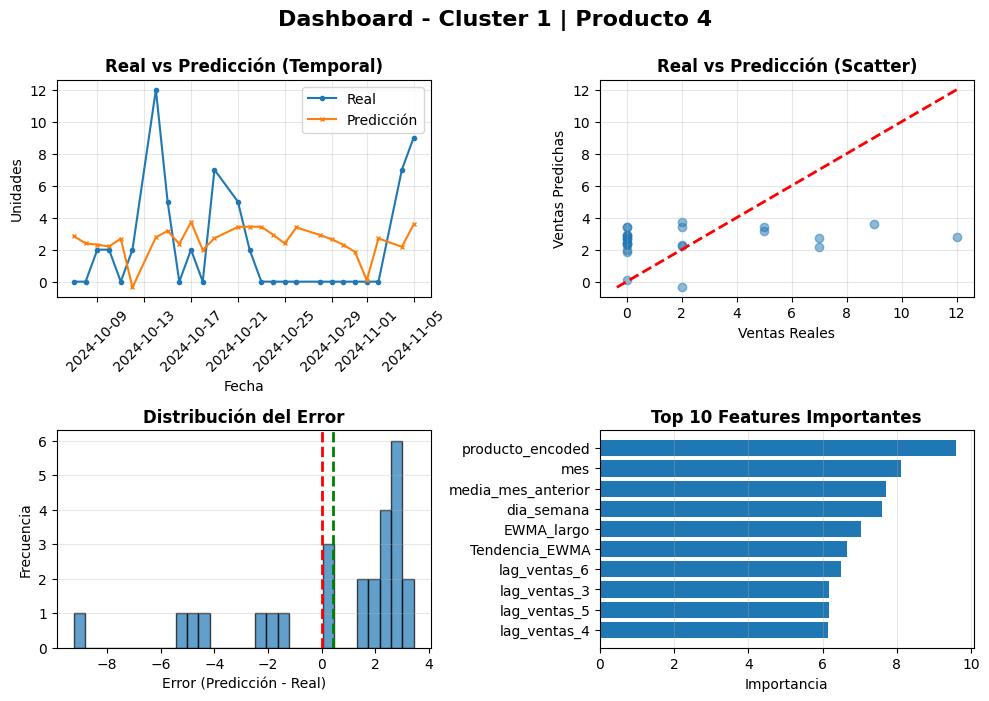


🔄 Entrenando modelo para Cluster 2...
   ✓ MAE: 3.73 | RMSE: 5.14 | R²: 0.1841


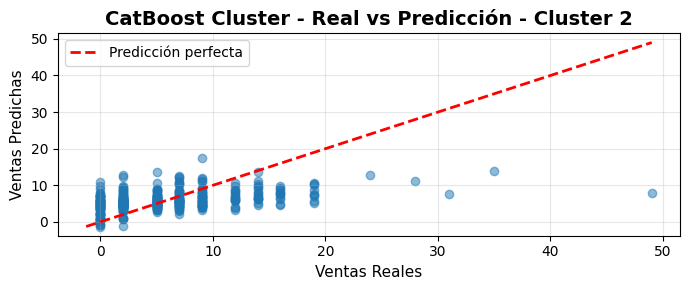

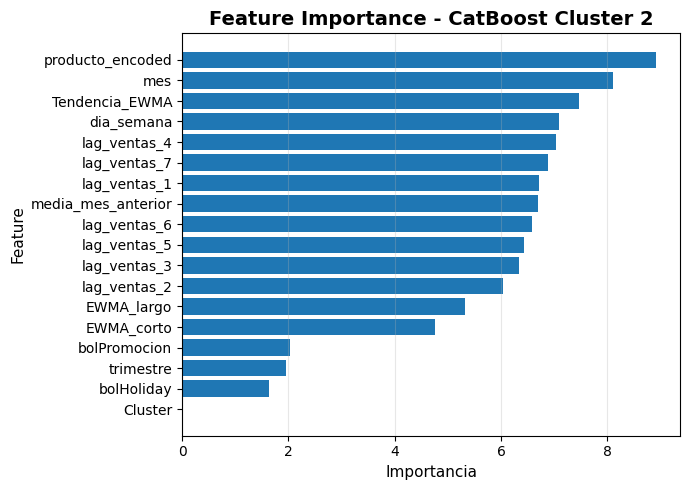

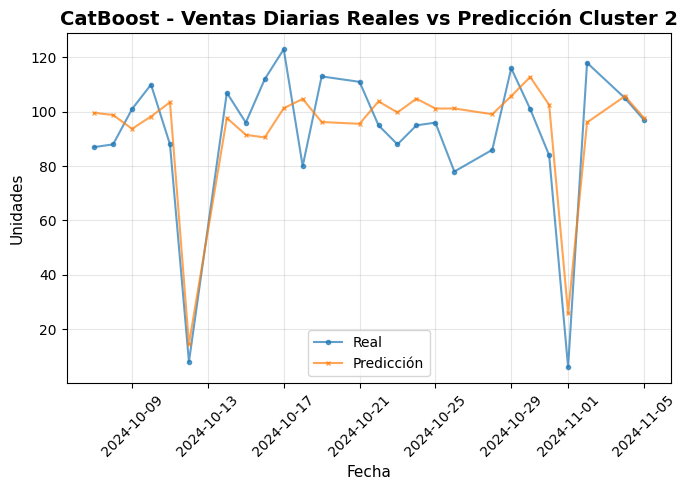


   📌 Producto representativo: 1 (26 registros)
   📊 Estadísticas del error:
      Error medio:              0.13
      Error abs medio:          3.73
      Error máximo:            41.06


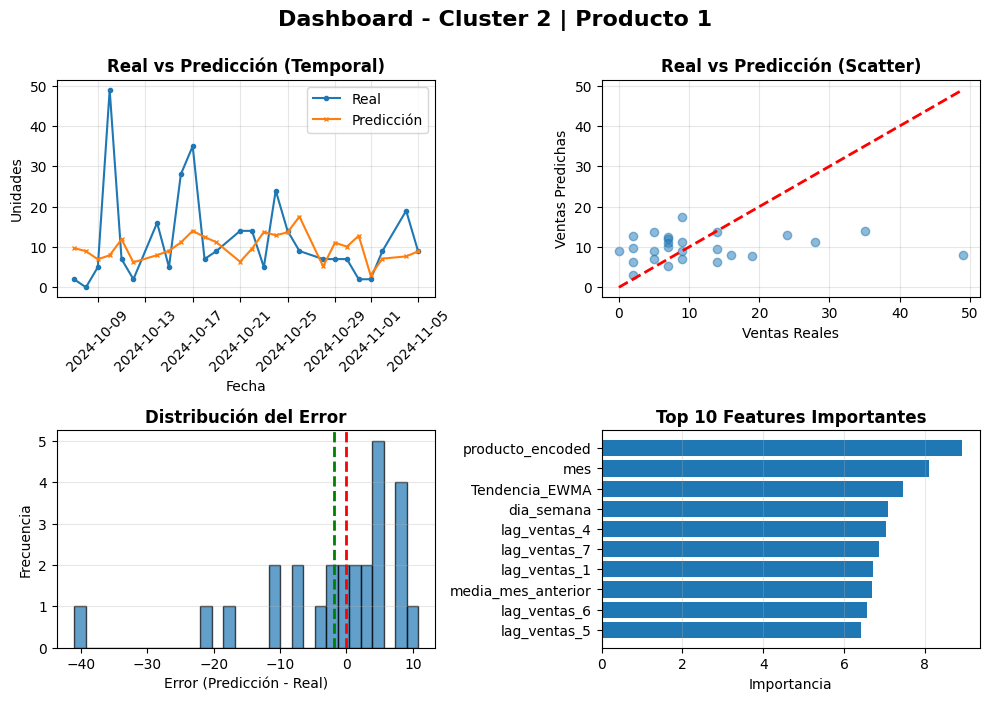


🔄 Entrenando modelo para Cluster 3...
   ✓ MAE: 1.09 | RMSE: 1.67 | R²: 0.0663


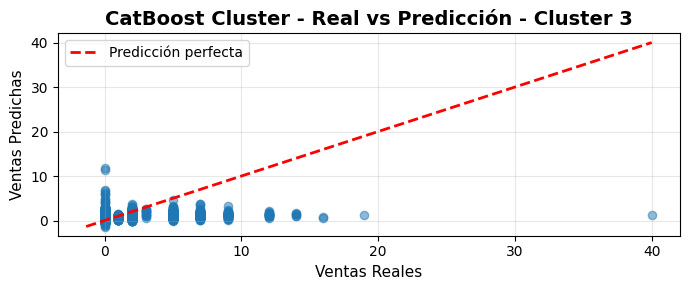

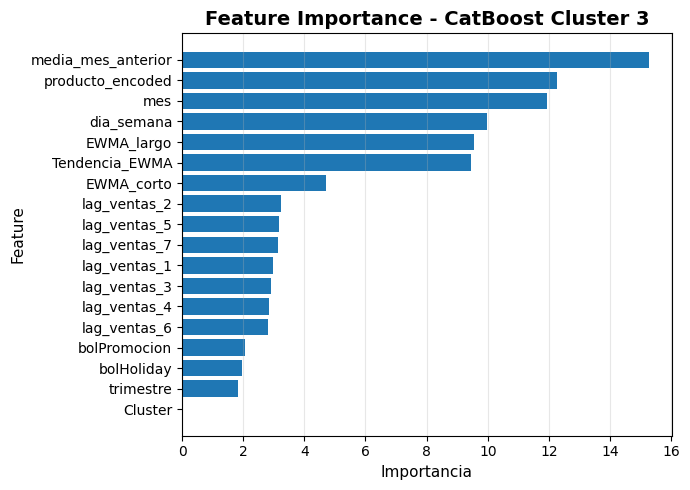

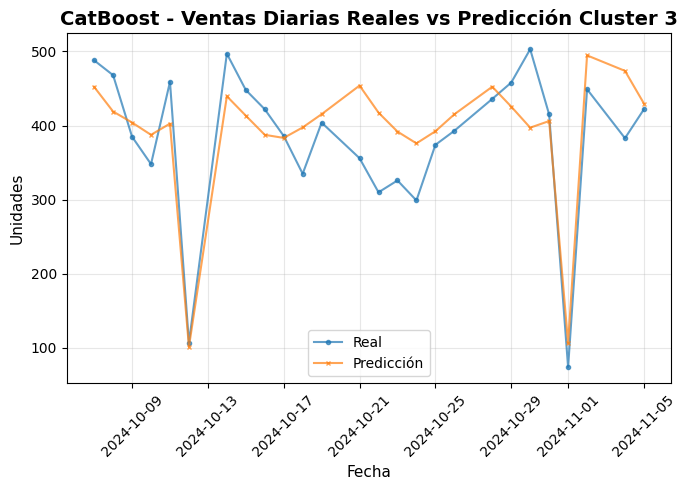


   📌 Producto representativo: 38 (26 registros)
   📊 Estadísticas del error:
      Error medio:              0.02
      Error abs medio:          1.09
      Error máximo:            38.72


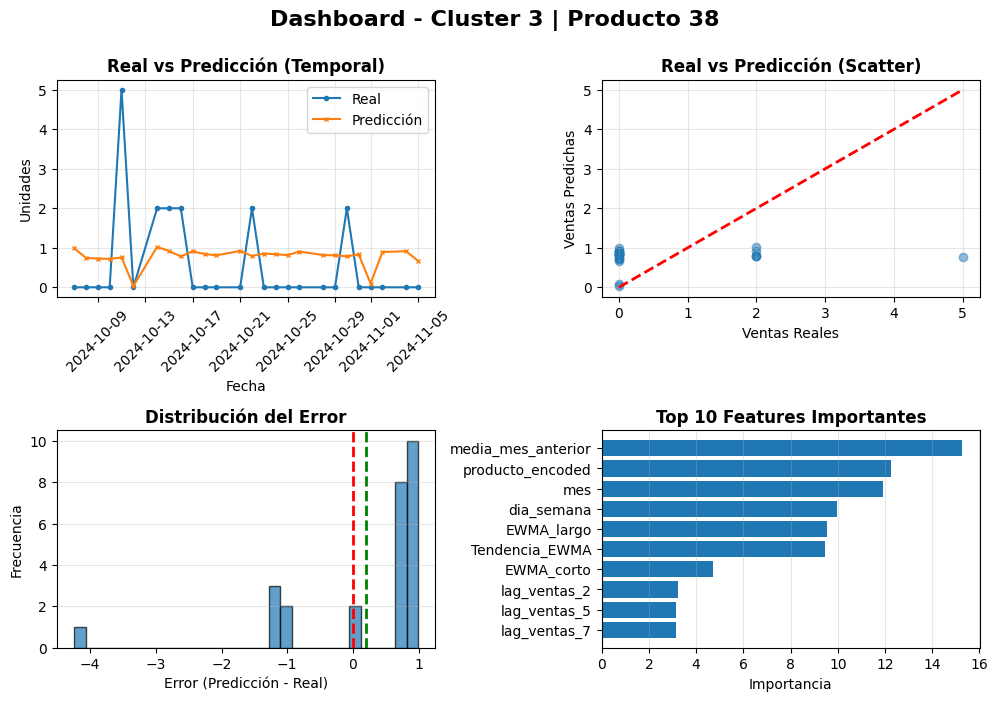

In [8]:

# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 2: CATBOOST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
      
    # Entrenar
    catboost_cluster = CatBoostRegressor(**best_params)
    
    catboost_cluster.fit(X_train_c, y_train_c, verbose=False)
    y_pred_c = catboost_cluster.predict(X_test_c)
    
    # Calcular métricas
    metricas_cluster = calcular_metricas(y_test_c, y_pred_c, f"CatBoost Cluster {cluster}")
    todas_metricas.append(metricas_cluster)
    
    print(f"   ✓ MAE: {metricas_cluster['MAE']:.2f} | RMSE: {metricas_cluster['RMSE']:.2f} | R²: {metricas_cluster['R2']:.4f}")
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz['error'] = y_pred_c - df_test_viz[TARGET]

    grafico_scatter_prediccion(
        df=df_test_viz,
        col_real=TARGET,
        col_pred='prediccion',
        titulo=f'CatBoost Cluster - Real vs Predicción - Cluster {cluster}',
        figsize=(7, 3)
    )

    grafico_feature_importance(
        modelo=catboost_cluster,
        feature_names=FEATURES,
        top_n=len(FEATURES),
        titulo=f'Feature Importance - CatBoost Cluster {cluster}',
        figsize=(7, 5)
    )

    # Crear dataframe con suma por día
    df_daily = df_test_viz.copy()
    df_daily['fecha'] = df_daily['idSecuencia'].dt.date
    df_daily_sum = df_daily.groupby('fecha')[[TARGET, 'prediccion']].sum().reset_index()
    grafico_real_vs_prediccion(
        df=df_daily_sum,
        col_real=TARGET,
        col_pred='prediccion',
        col_fecha='fecha',
        titulo=f'CatBoost - Ventas Diarias Reales vs Predicción Cluster {cluster}',
        figsize=(7, 5)
    )
    
    # Preparar datos para visualización de producto representativo
    test_cluster_pred = test_cluster.copy()
    test_cluster_pred['prediccion'] = y_pred_c
    test_cluster_pred['error'] = y_pred_c - test_cluster_pred[TARGET]
    test_cluster_pred['error_abs'] = np.abs(test_cluster_pred['error'])
    
    # Seleccionar producto representativo
    producto_rep = test_cluster['producto'].value_counts().index[0]
    df_producto = test_cluster_pred[test_cluster_pred['producto'] == producto_rep].copy()
    df_producto = df_producto.sort_values('idSecuencia')
    
    print(f"\n   📌 Producto representativo: {producto_rep} ({len(df_producto)} registros)")
    
    # Estadísticas
    print(f"   📊 Estadísticas del error:")
    print(f"      Error medio:          {test_cluster_pred['error'].mean():>8.2f}")
    print(f"      Error abs medio:      {test_cluster_pred['error_abs'].mean():>8.2f}")
    print(f"      Error máximo:         {test_cluster_pred['error_abs'].max():>8.2f}")
    
    dashboard_prediccion(
        df=df_producto,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=catboost_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster} | Producto {producto_rep}',
        figsize=(10, 7)
    )



🔍 MODELO 3: CATBOOST POR PRODUCTO (TOP 10)

🏆 Top 10 productos: [1, 2, 9, 78, 7, 13, 15, 391, 3, 131]

🔄 Entrenando modelo para Producto 1...
   ✓ MAE: 8.64 | RMSE: 12.22 | R²: -0.2036

   📌 Producto 1
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         2   11.082544 9.082544   9.082544
    2024-10-08         0    8.139896 8.139896   8.139896
    2024-10-09         5    7.124817 2.124817   2.124817

   📊 Estadísticas del error:
      Error medio:             -1.74
      Error abs medio:          8.64
      Error máximo:            40.43
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 1 8.6426 149.3346 12.2203 -0.2036    119.23      75.68 0.7694    73.19

🏆 Mejor modelo: CatBoost Producto 1 (RMSE: 12.2203)


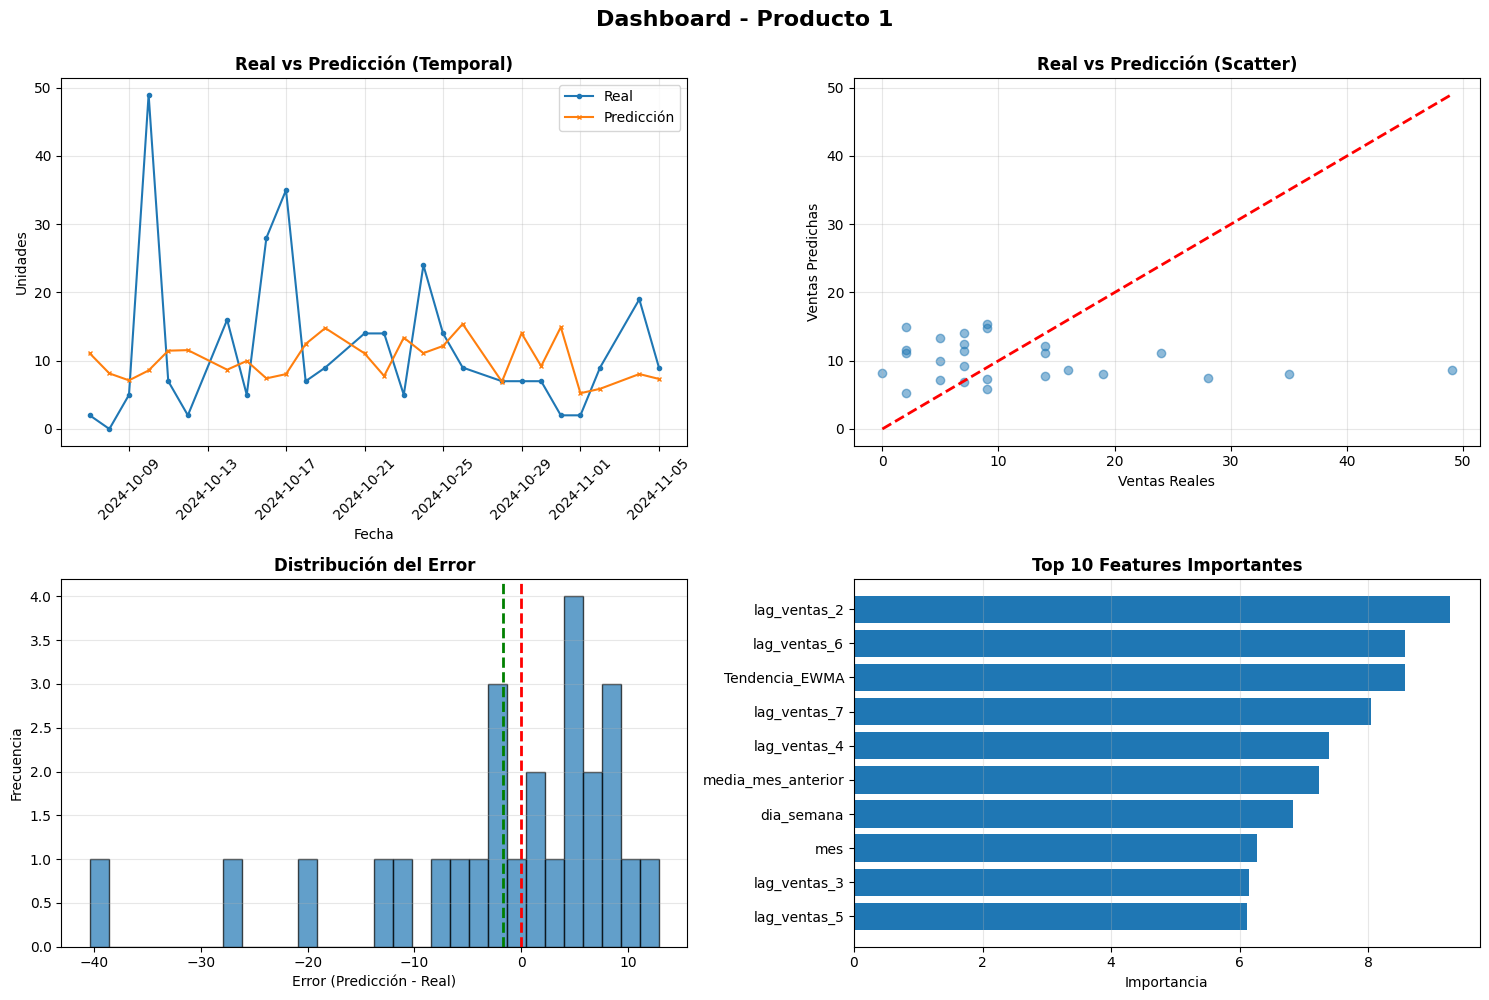


🔄 Entrenando modelo para Producto 2...
   ✓ MAE: 3.68 | RMSE: 4.68 | R²: -0.0706

   📌 Producto 2
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    7.813034  0.813034   0.813034
    2024-10-08         7    7.490950  0.490950   0.490950
    2024-10-09        16    8.137147 -7.862853   7.862853

   📊 Estadísticas del error:
      Error medio:              1.44
      Error abs medio:          3.68
      Error máximo:             8.67
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 2 3.6782 21.8874 4.6784 -0.0706     91.05      66.96   0.65    58.31

🏆 Mejor modelo: CatBoost Producto 2 (RMSE: 4.6784)


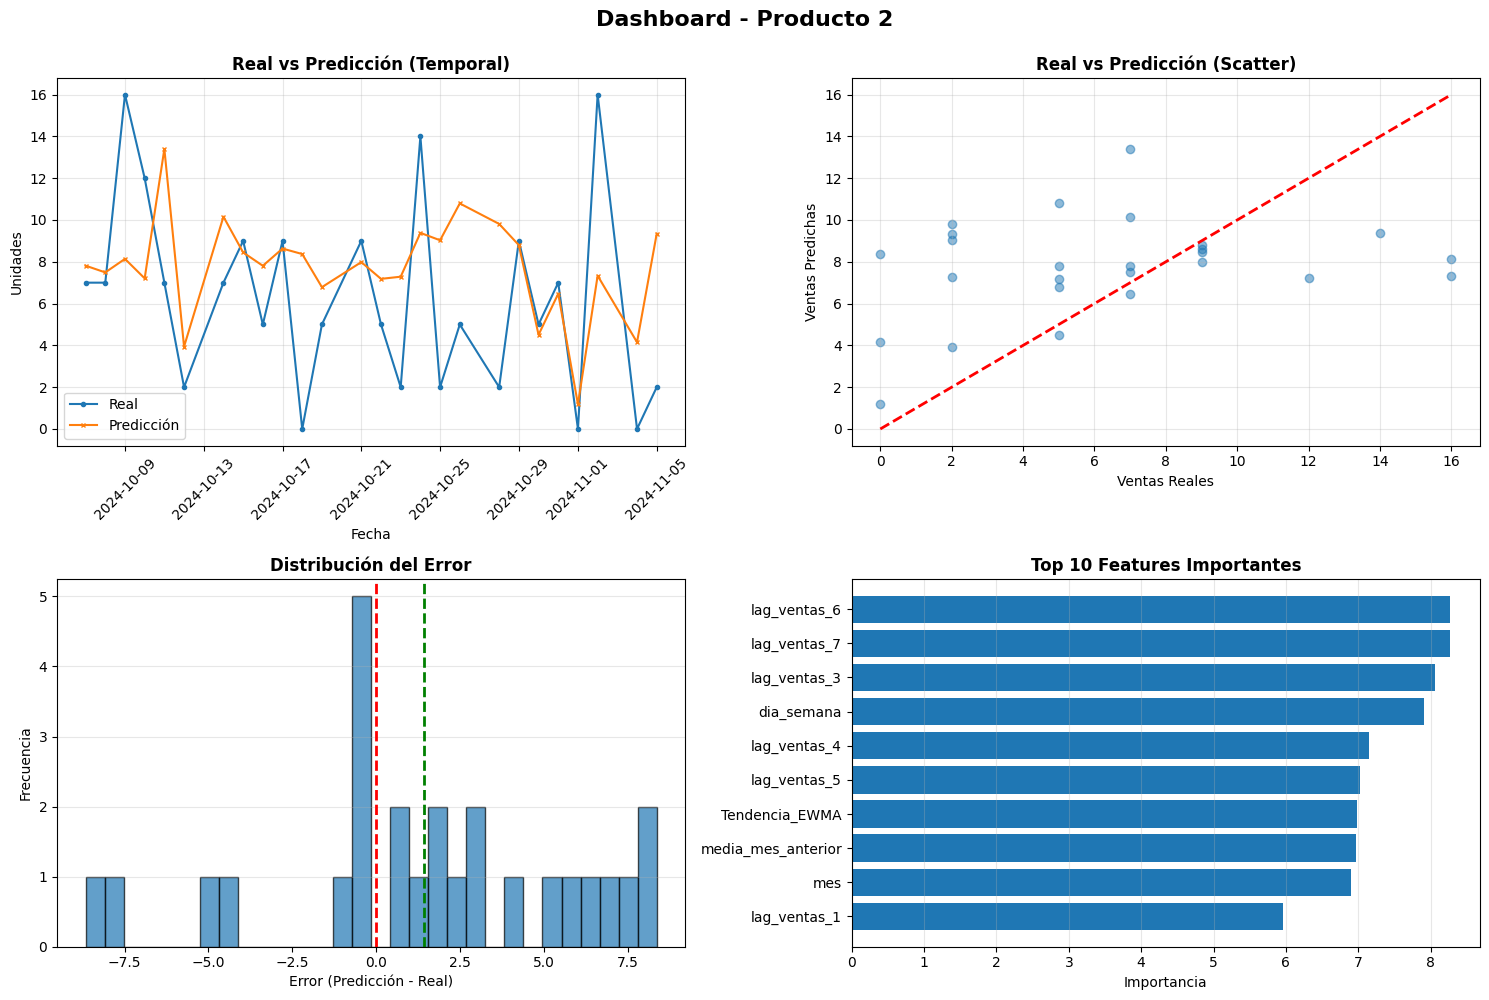


🔄 Entrenando modelo para Producto 9...
   ✓ MAE: 5.39 | RMSE: 5.96 | R²: -0.1553

   📌 Producto 9
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         9    8.036709 -0.963291   0.963291
    2024-10-08         2   10.526357  8.526357   8.526357
    2024-10-09         5    8.962282  3.962282   3.962282

   📊 Estadísticas del error:
      Error medio:              1.59
      Error abs medio:          5.39
      Error máximo:            11.99
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 9 5.3888 35.563 5.9635 -0.1553    143.48      92.62 0.7966     83.9

🏆 Mejor modelo: CatBoost Producto 9 (RMSE: 5.9635)


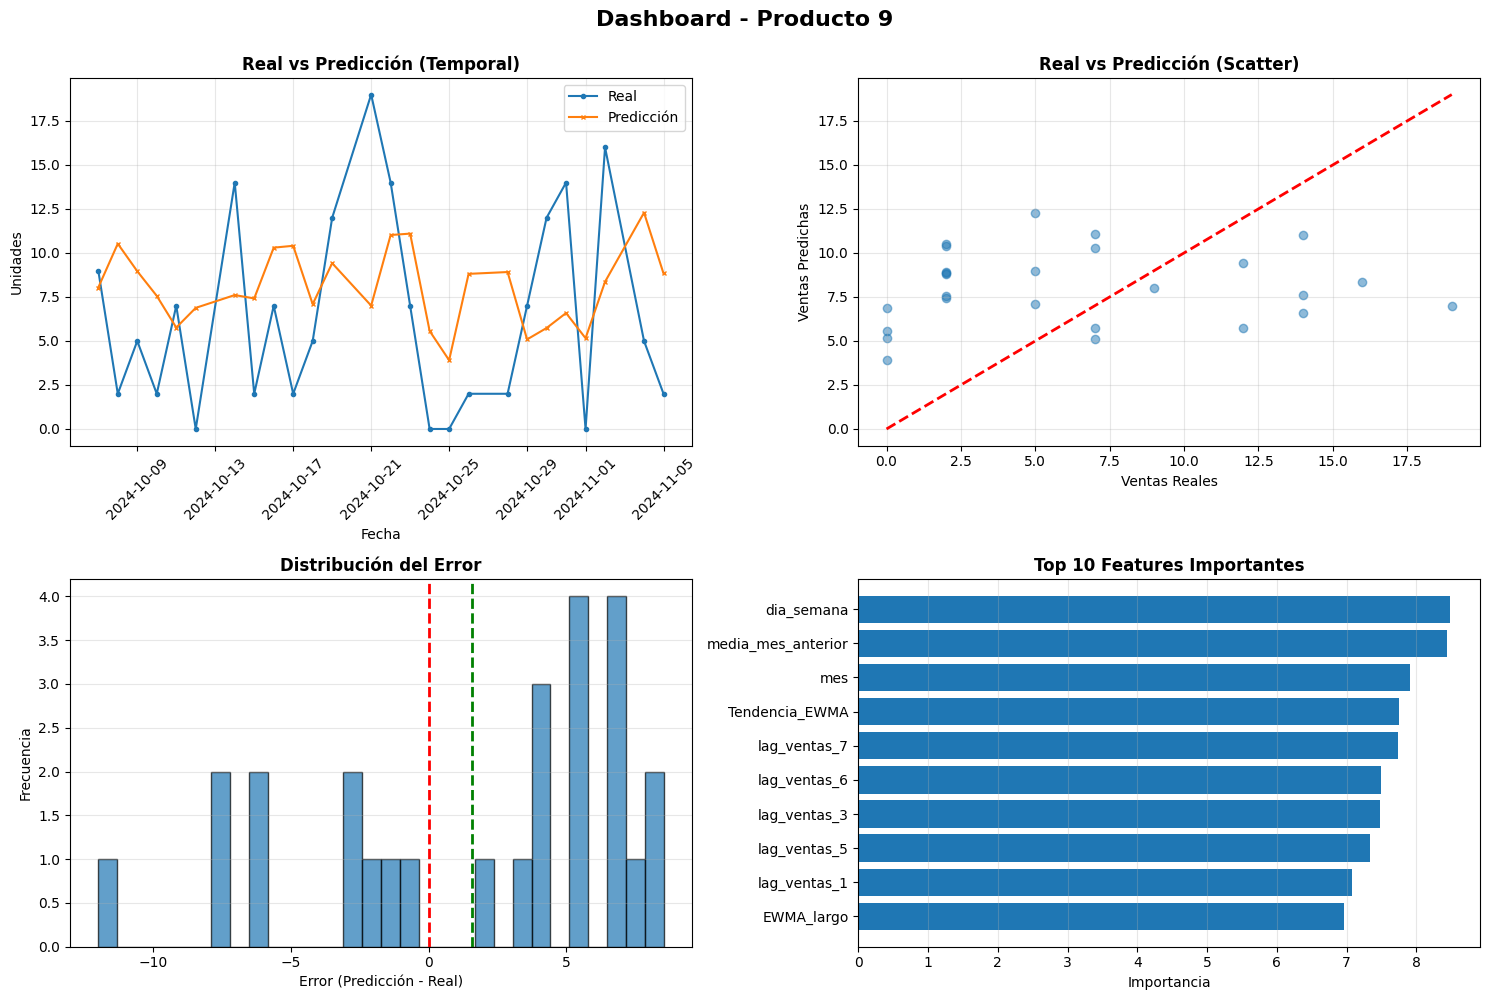


🔄 Entrenando modelo para Producto 78...
   ✓ MAE: 5.22 | RMSE: 6.74 | R²: 0.1138

   📌 Producto 78
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion      error  error_abs
    2024-10-07        16   10.630531  -5.369469   5.369469
    2024-10-08        16    5.217323 -10.782677  10.782677
    2024-10-09        14   11.145529  -2.854471   2.854471

   📊 Estadísticas del error:
      Error medio:             -1.12
      Error abs medio:          5.22
      Error máximo:            21.42
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 78 5.2151 45.4506 6.7417 0.1138      66.6      63.41 0.6707    46.12

🏆 Mejor modelo: CatBoost Producto 78 (RMSE: 6.7417)


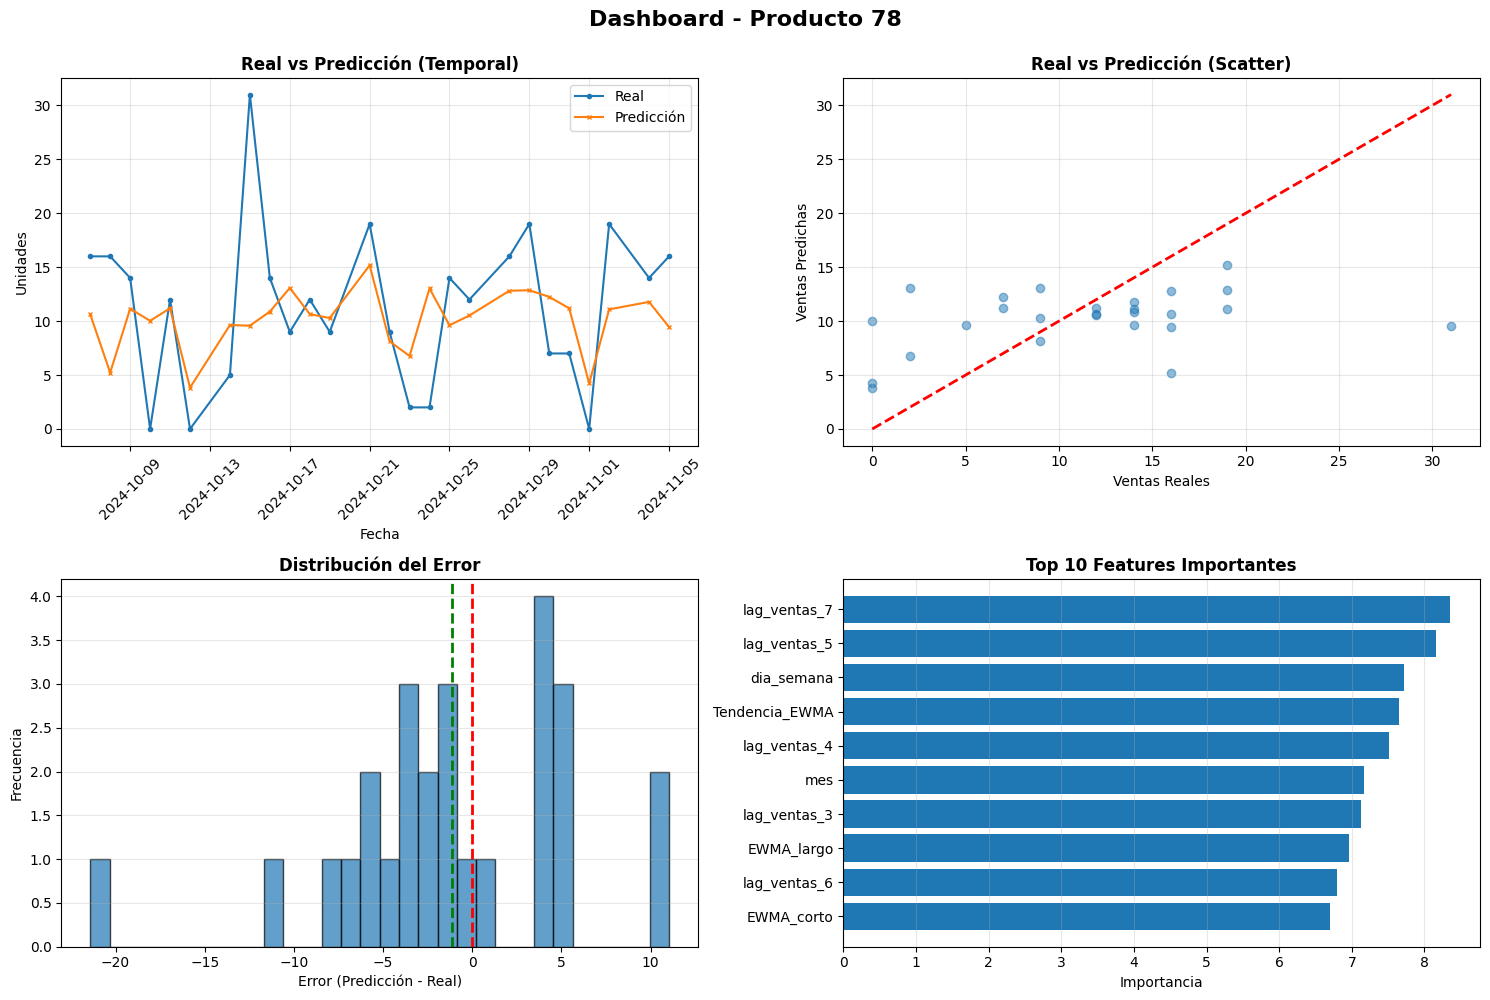


🔄 Entrenando modelo para Producto 7...
   ✓ MAE: 4.12 | RMSE: 4.44 | R²: -1.5554

   📌 Producto 7
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         0    5.072643 5.072643   5.072643
    2024-10-08         0    6.184569 6.184569   6.184569
    2024-10-09         0    6.494452 6.494452   6.494452

   📊 Estadísticas del error:
      Error medio:              3.05
      Error abs medio:          4.12
      Error máximo:             6.49
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 7 4.1186 19.7027 4.4388 -1.5554    126.42      121.5 1.0817   162.25

🏆 Mejor modelo: CatBoost Producto 7 (RMSE: 4.4388)


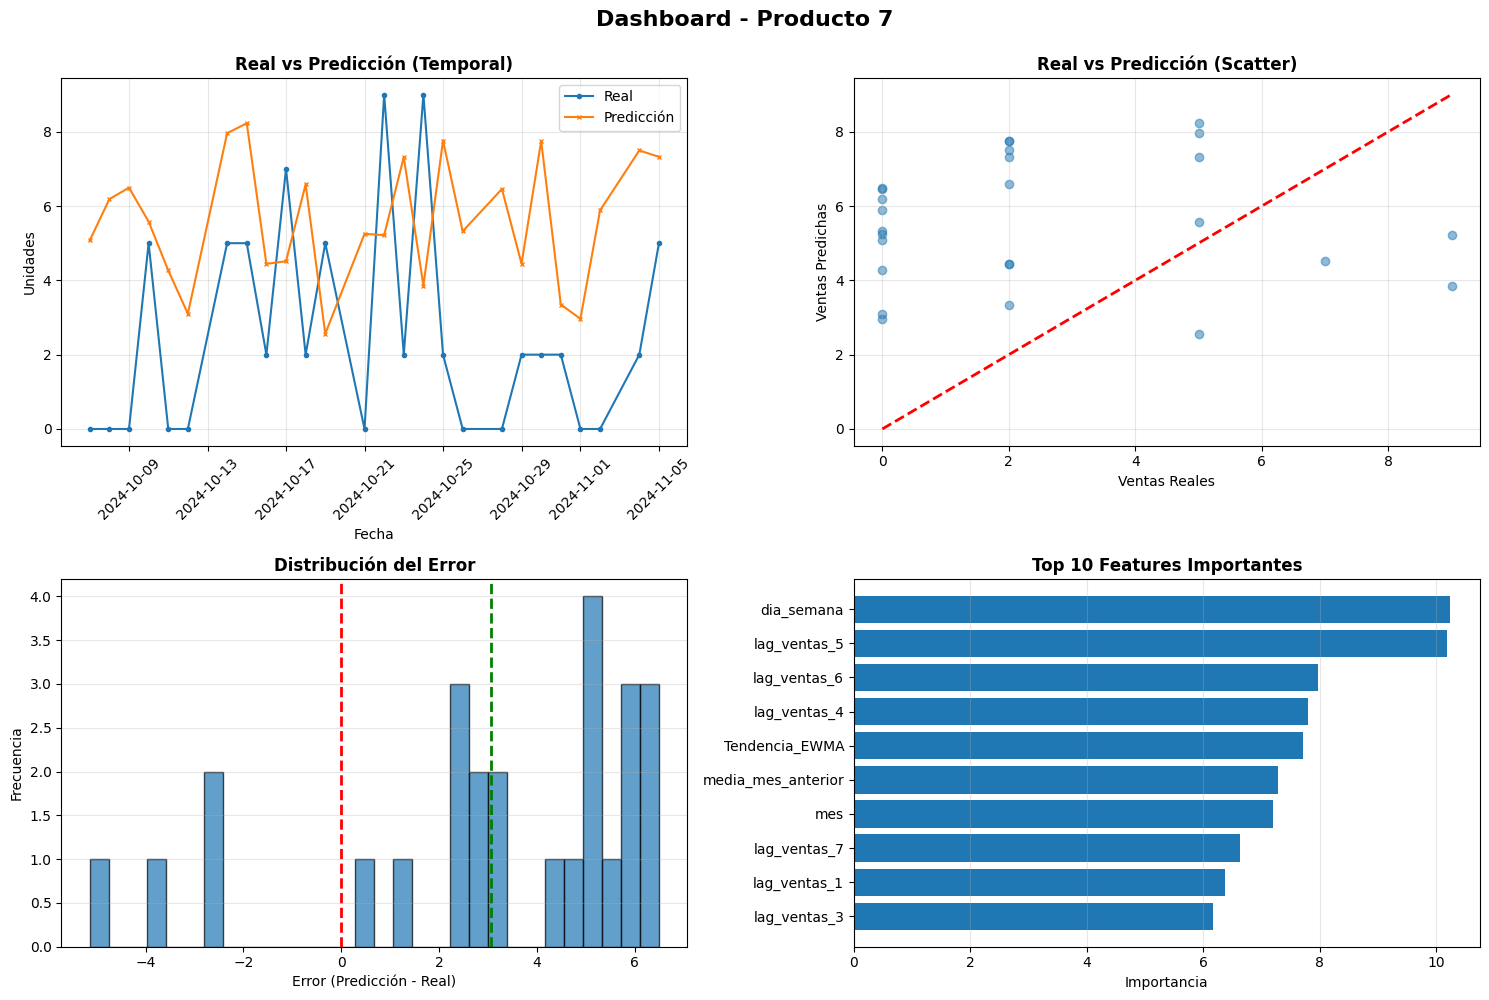


🔄 Entrenando modelo para Producto 13...
   ✓ MAE: 3.35 | RMSE: 3.87 | R²: -0.2913

   📌 Producto 13
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         2    6.826512 4.826512   4.826512
    2024-10-08         2    7.343821 5.343821   5.343821
    2024-10-09         2    3.934964 1.934964   1.934964

   📊 Estadísticas del error:
      Error medio:              1.47
      Error abs medio:          3.35
      Error máximo:             8.06
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 13 3.3466 14.9469 3.8661 -0.2913     99.59      84.22 0.7391    84.48

🏆 Mejor modelo: CatBoost Producto 13 (RMSE: 3.8661)


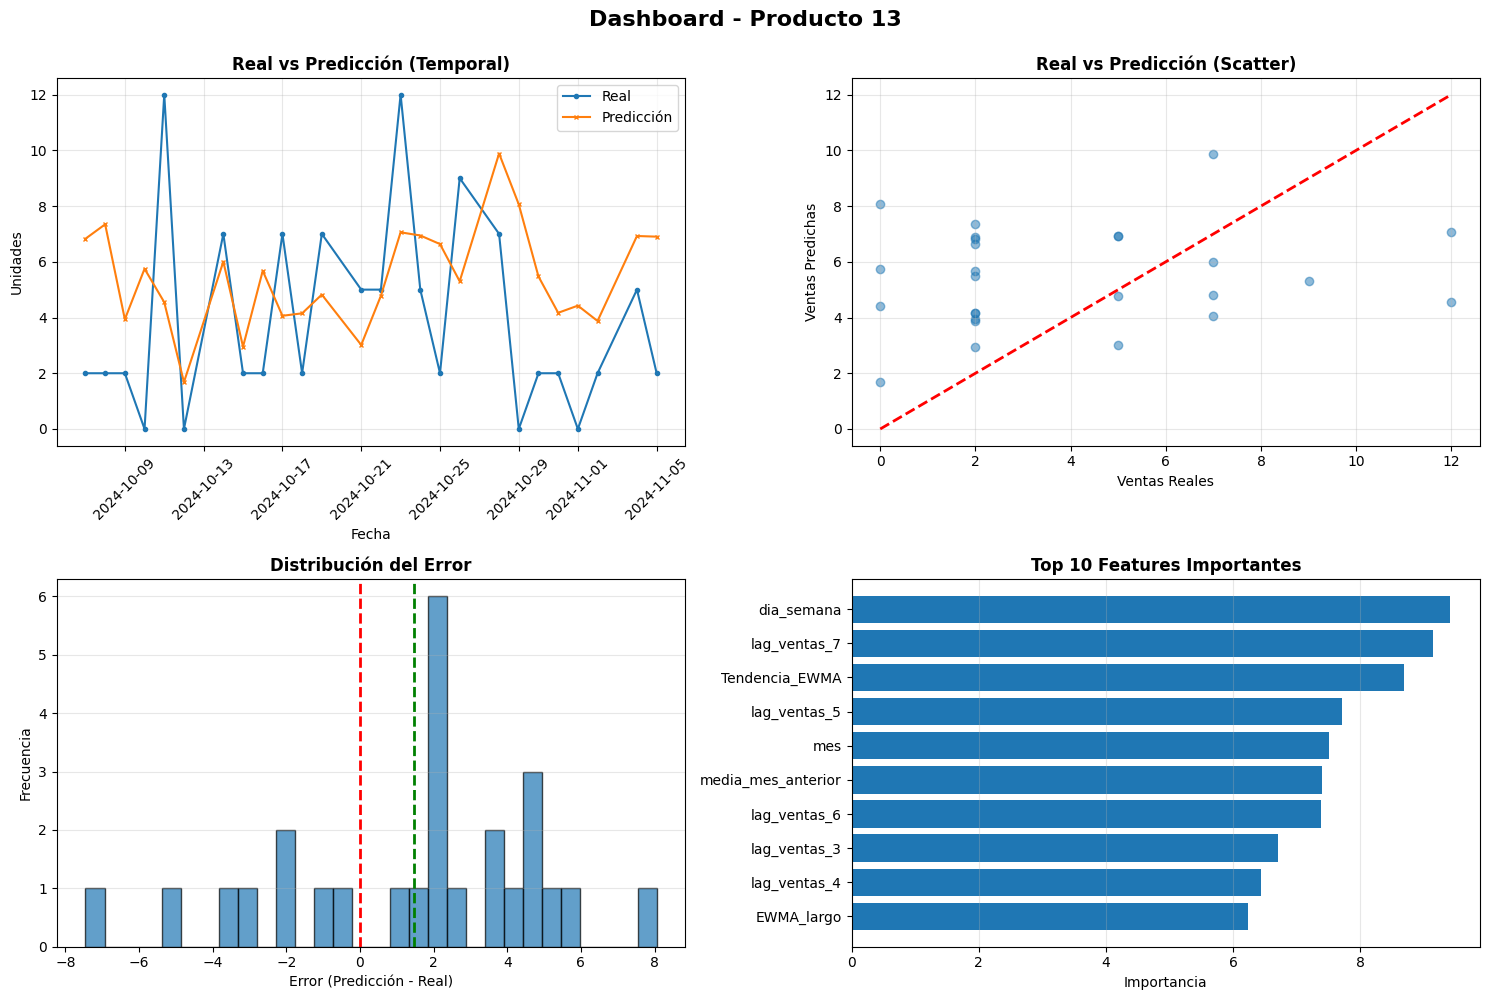


🔄 Entrenando modelo para Producto 15...
   ✓ MAE: 2.96 | RMSE: 3.65 | R²: 0.1685

   📌 Producto 15
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    6.207782 -0.792218   0.792218
    2024-10-08         5    6.272423  1.272423   1.272423
    2024-10-09         9    5.975516 -3.024484   3.024484

   📊 Estadísticas del error:
      Error medio:             -0.10
      Error abs medio:          2.96
      Error máximo:             8.10
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 15 2.9584 13.2896 3.6455 0.1685     53.86      67.31 0.6985    51.97

🏆 Mejor modelo: CatBoost Producto 15 (RMSE: 3.6455)


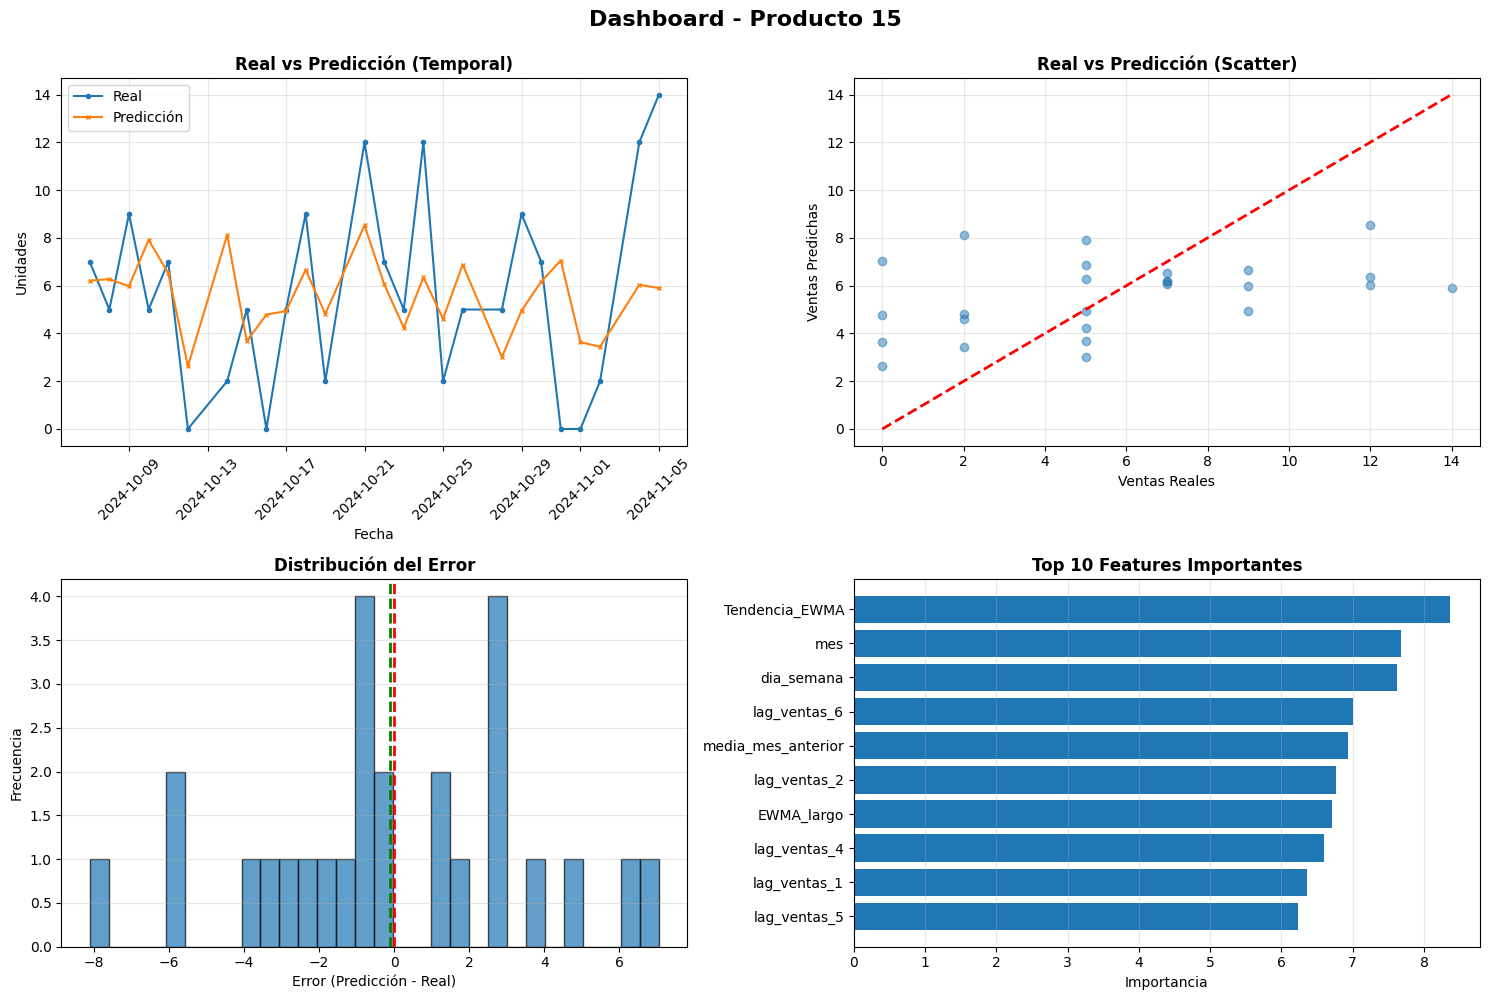


🔄 Entrenando modelo para Producto 391...
   ✓ MAE: 3.00 | RMSE: 3.77 | R²: -0.0053

   📌 Producto 391
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         5    5.237810  0.237810   0.237810
    2024-10-08         9    7.463726 -1.536274   1.536274
    2024-10-09         0    5.210089  5.210089   5.210089

   📊 Estadísticas del error:
      Error medio:              1.05
      Error abs medio:          3.00
      Error máximo:             9.83
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE     MSE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 391 3.0028 14.2352 3.773 -0.0053     65.24     100.71 0.6716    88.72

🏆 Mejor modelo: CatBoost Producto 391 (RMSE: 3.7730)


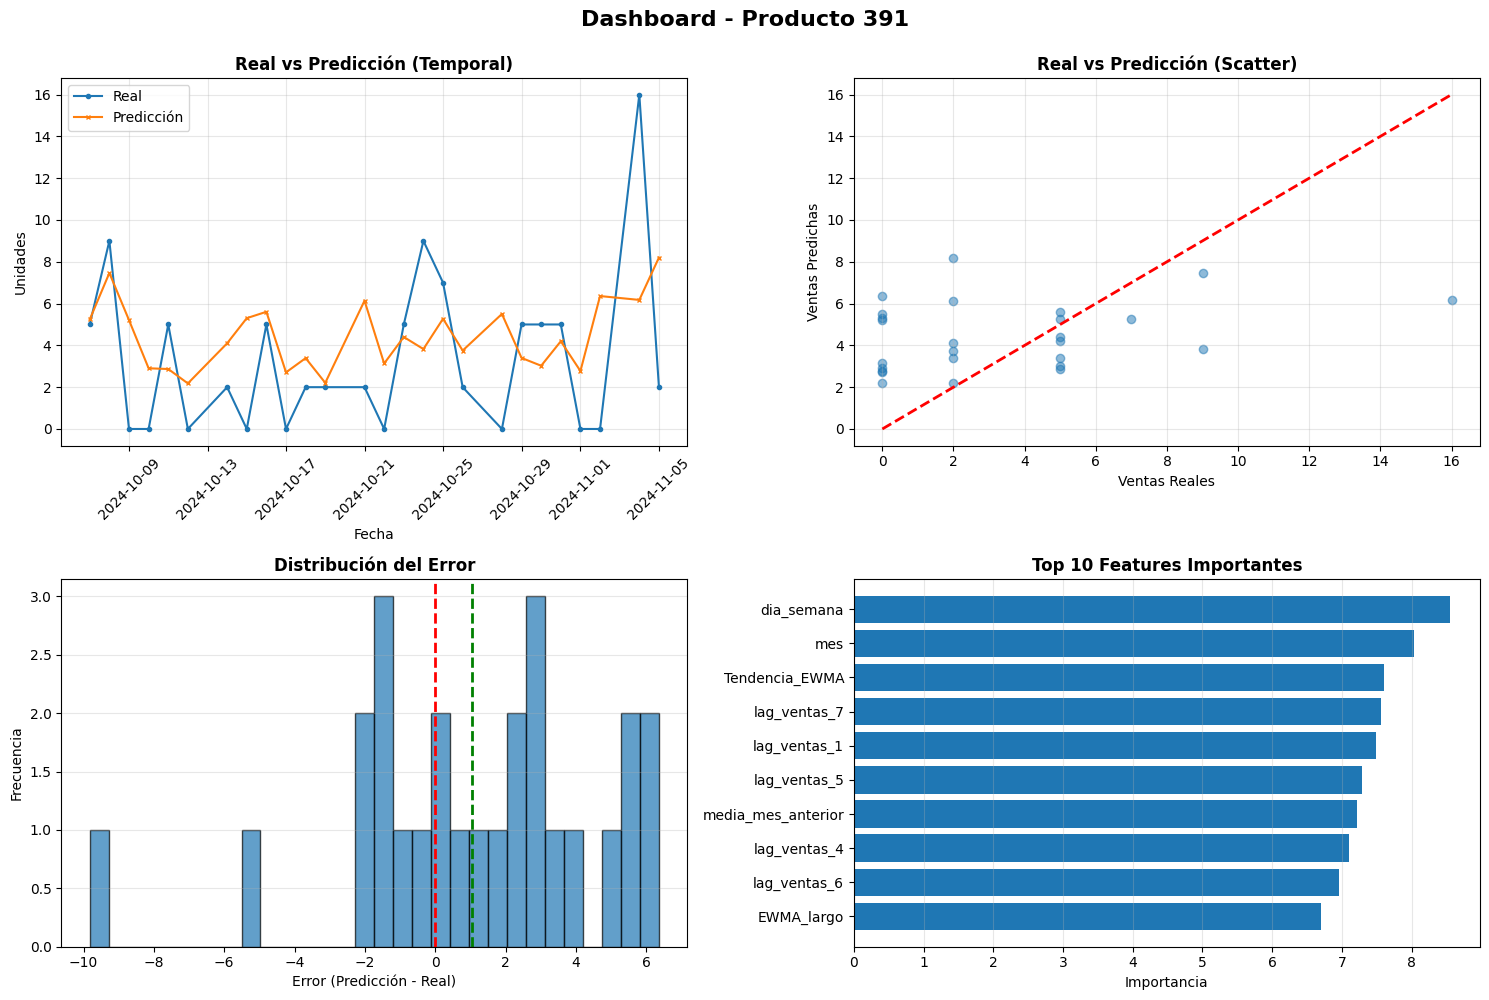


🔄 Entrenando modelo para Producto 3...
   ✓ MAE: 4.50 | RMSE: 5.80 | R²: -0.1084

   📌 Producto 3
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    3.892726 -3.107274   3.107274
    2024-10-08         5    3.338909 -1.661091   1.661091
    2024-10-09         5    5.139991  0.139991   0.139991

   📊 Estadísticas del error:
      Error medio:             -0.64
      Error abs medio:          4.50
      Error máximo:            15.37
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 3 4.4953 33.6063 5.7971 -0.1084     73.09      87.19 0.9827    69.99

🏆 Mejor modelo: CatBoost Producto 3 (RMSE: 5.7971)


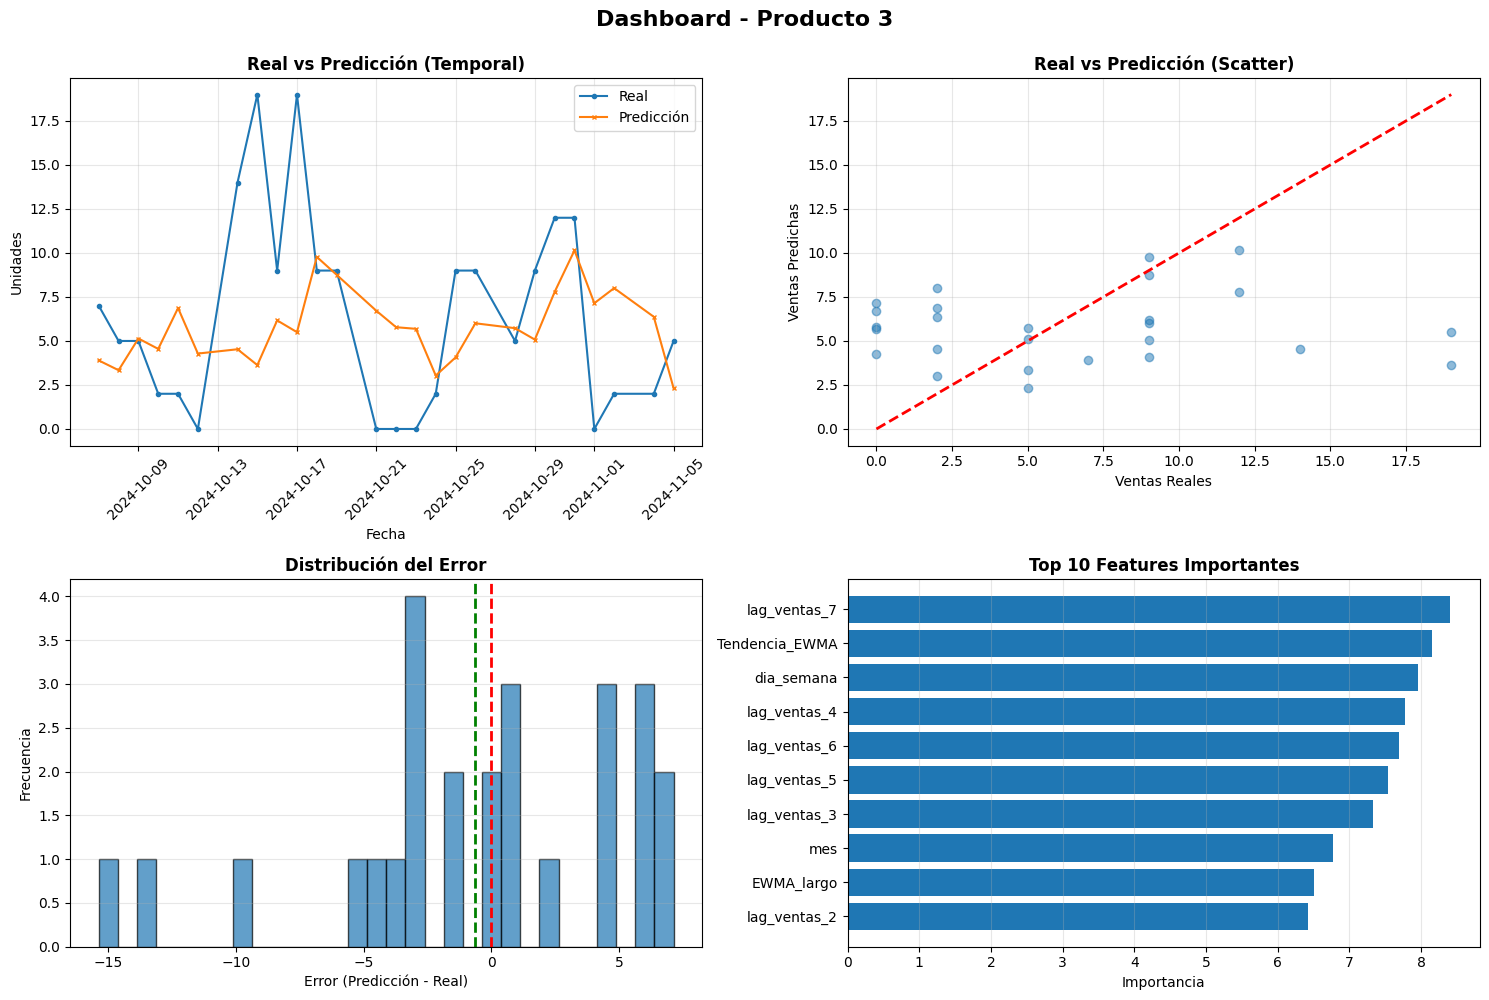


🔄 Entrenando modelo para Producto 131...
   ✓ MAE: 3.10 | RMSE: 3.70 | R²: 0.0802

   📌 Producto 131
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         9    4.415567 -4.584433   4.584433
    2024-10-08         9    9.036765  0.036765   0.036765
    2024-10-09         2    8.438342  6.438342   6.438342

   📊 Estadísticas del error:
      Error medio:              0.58
      Error abs medio:          3.10
      Error máximo:             6.44
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 131 3.0995 13.6954 3.7007 0.0802     61.67      98.72 0.7303    83.08

🏆 Mejor modelo: CatBoost Producto 131 (RMSE: 3.7007)


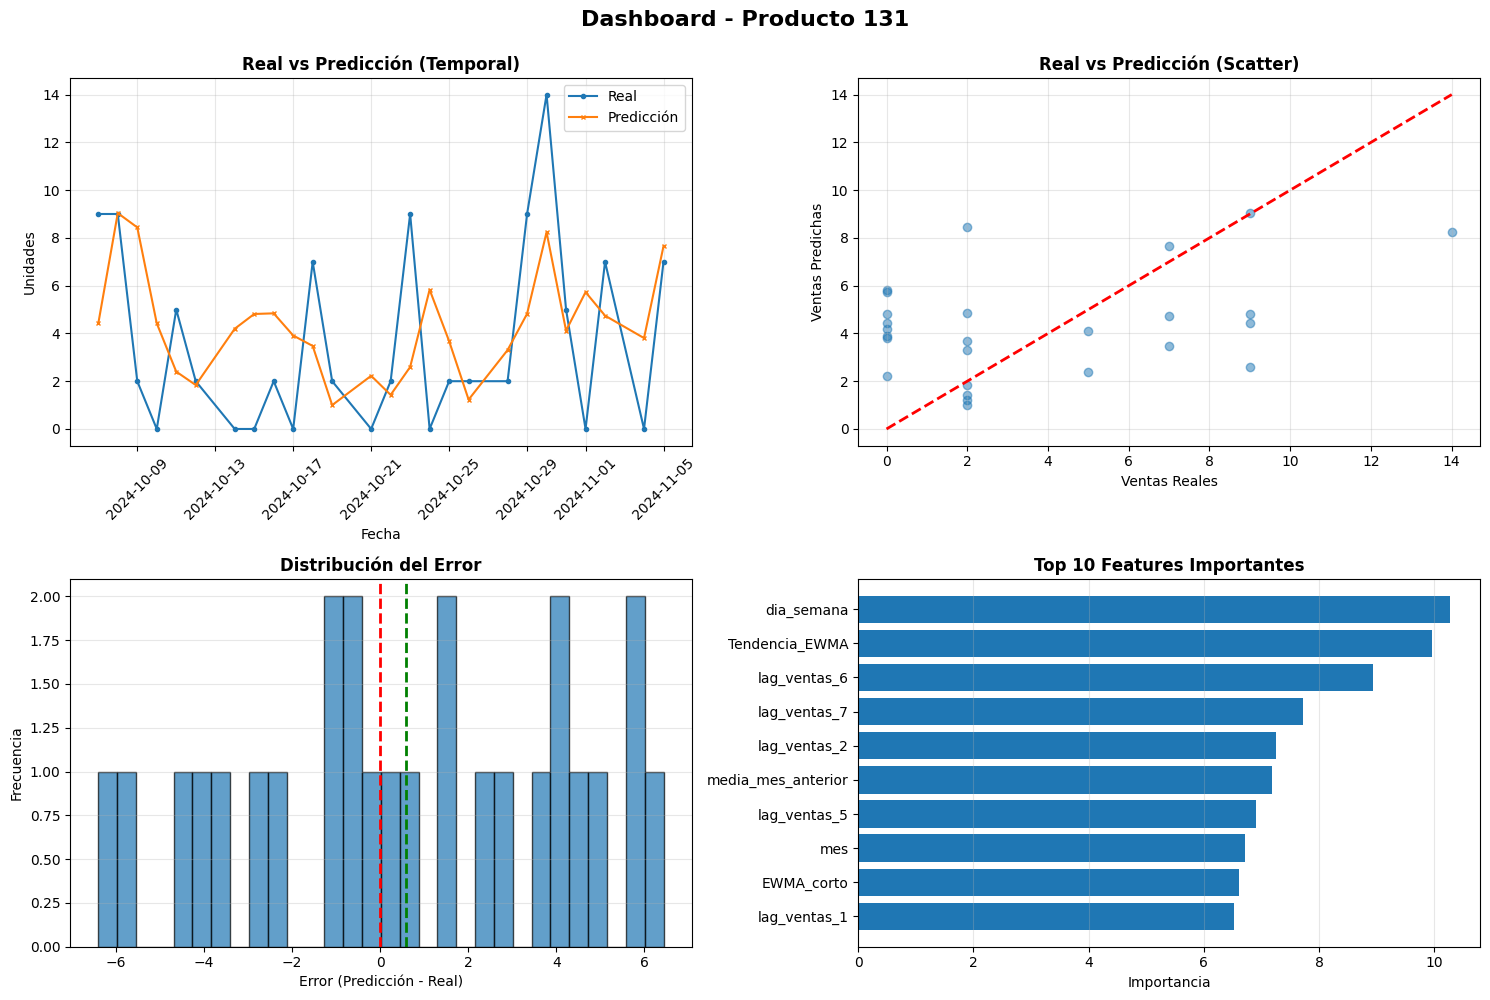

In [9]:

# ============================================================================
# 3. MODELOS POR PRODUCTO (TOP 10)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 3: CATBOOST POR PRODUCTO (TOP 10)")
print("="*100)

top_productos = df_train.groupby('producto')['udsVenta'].sum().nlargest(10).index.tolist()
print(f"\n🏆 Top 10 productos: {top_productos}")

modelos_producto = {}

for producto in top_productos:
    print(f"\n🔄 Entrenando modelo para Producto {producto}...")
    
    # Filtrar datos
    train_prod = df_train[df_train['producto'] == producto]
    test_prod = df_test[df_test['producto'] == producto].dropna()
    
    if len(test_prod) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    if len(train_prod) < 100:
        print(f"   ⚠️  Datos insuficientes ({len(train_prod)} registros)")
        continue
    
    X_train_p = train_prod[FEATURES]
    y_train_p = train_prod[TARGET]
    X_test_p = test_prod[FEATURES]
    y_test_p = test_prod[TARGET]
    
    # Entrenar
    catboost_producto = CatBoostRegressor(**best_params)
    
    catboost_producto.fit(X_train_p, y_train_p, verbose=False)
    y_pred_p = catboost_producto.predict(X_test_p)
    
    modelos_producto[producto] = catboost_producto
    
    # Calcular métricas
    metricas_producto = calcular_metricas(y_test_p, y_pred_p, f"CatBoost Producto {producto}")
    todas_metricas.append(metricas_producto)
    
    print(f"   ✓ MAE: {metricas_producto['MAE']:.2f} | RMSE: {metricas_producto['RMSE']:.2f} | R²: {metricas_producto['R2']:.4f}")
    
    # Preparar datos
    test_prod_pred = test_prod.copy()
    test_prod_pred['prediccion'] = y_pred_p
    test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
    test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
    test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / test_prod_pred[TARGET]) * 100
    test_prod_pred = test_prod_pred.sort_values('idSecuencia')
    
    print(f"\n   📌 Producto {producto}")
    print(f"      Train: {len(train_prod)} | Test: {len(test_prod_pred)}")
    
    # Primeras predicciones
    print(f"\n   📋 Primeras 3 predicciones:")
    cols = ['idSecuencia', TARGET, 'prediccion', 'error', 'error_abs']
    print("   " + test_prod_pred[cols].head(3).to_string(index=False).replace('\n', '\n   '))
    
    # Estadísticas
    print(f"\n   📊 Estadísticas del error:")
    print(f"      Error medio:          {test_prod_pred['error'].mean():>8.2f}")
    print(f"      Error abs medio:      {test_prod_pred['error_abs'].mean():>8.2f}")
    print(f"      Error máximo:         {test_prod_pred['error_abs'].max():>8.2f}")
    print(f"      Error % medio:        {test_prod_pred['error_pct'].mean():>8.2f}%")
    
    if len(test_prod_pred) >= 2:
        resumen_metricas([metricas_producto])
        
        try:
            dashboard_prediccion(
                df=test_prod_pred,
                col_fecha='idSecuencia',
                col_real=TARGET,
                col_pred='prediccion',
                modelo=catboost_producto,
                feature_names=FEATURES,
                titulo_principal=f'Dashboard - Producto {producto}',
                figsize=(15, 10),
            )
        except Exception as e:
            print(f"   ⚠️  Error en dashboard: {str(e)}")



🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   CatBoost Cluster 3 1.0853   2.7866  1.6693  0.0663     55.76     169.24 0.7491   133.64
 CatBoost Global Test 1.5713   5.6283  2.3724  0.2655     49.80     144.64 0.7270    96.23
   CatBoost Cluster 0 1.8029   6.4585  2.5414  0.1226     40.03     125.94 0.7306    93.37
   CatBoost Cluster 1 2.7923  13.1175  3.6218  0.1275     56.45      99.18 0.7239    73.23
 CatBoost Producto 15 2.9584  13.2896  3.6455  0.1685     53.86      67.31 0.6985    51.97
CatBoost Producto 131 3.0995  13.6954  3.7007  0.0802     61.67      98.72 0.7303    83.08
CatBoost Producto 391 3.0028  14.2352  3.7730 -0.0053     65.24     100.71 0.6716    88.72
 CatBoost Producto 13 3.3466  14.9469  3.8661 -0.2913     99.59      84.22 0.7391    84.48
  CatBoost Producto 7 4.1186  19.7027  4.4388 -1.5554    126.42     121.

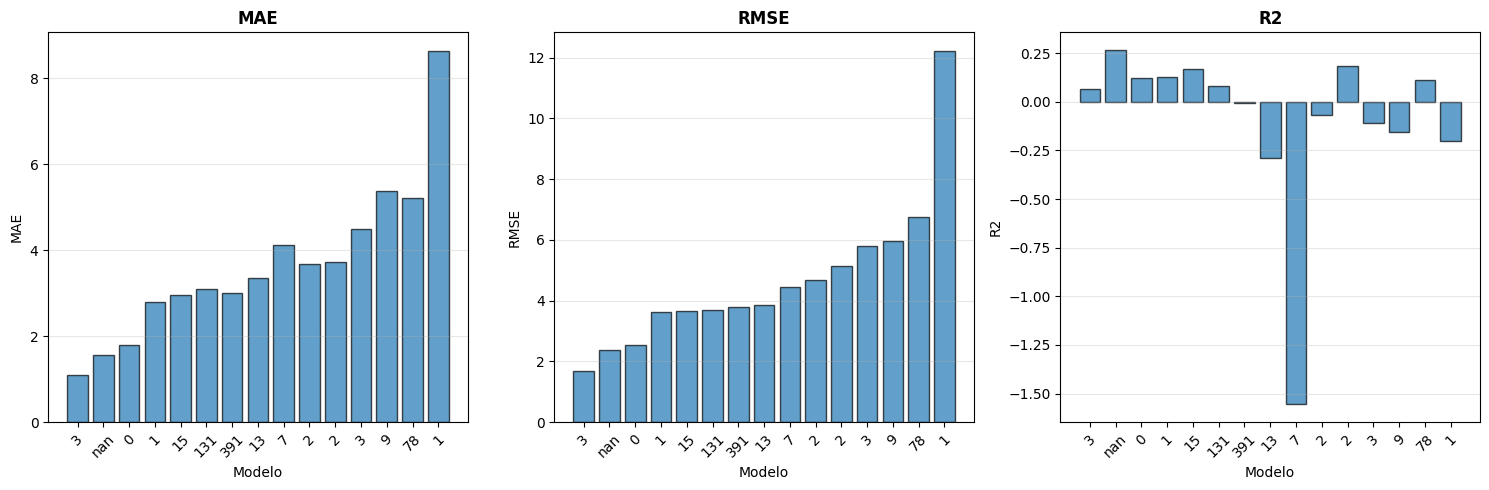


📊 ANÁLISIS POR CATEGORÍAS DE MODELOS

🌍 MODELOS GLOBALES:
           Algoritmo    MAE   RMSE     R2
CatBoost Global Test 1.5713 2.3724 0.2655

   Promedio RMSE: 2.37

🎯 MODELOS POR CLUSTER:
         Algoritmo    MAE   RMSE     R2
CatBoost Cluster 3 1.0853 1.6693 0.0663
CatBoost Cluster 0 1.8029 2.5414 0.1226
CatBoost Cluster 1 2.7923 3.6218 0.1275
CatBoost Cluster 2 3.7307 5.1383 0.1841

   Promedio RMSE: 3.24
   Mejor cluster: CatBoost Cluster 3 (RMSE: 1.67)
   Peor cluster: CatBoost Cluster 2 (RMSE: 5.14)

🛒 MODELOS POR PRODUCTO:
            Algoritmo    MAE    RMSE      R2
 CatBoost Producto 15 2.9584  3.6455  0.1685
CatBoost Producto 131 3.0995  3.7007  0.0802
CatBoost Producto 391 3.0028  3.7730 -0.0053
 CatBoost Producto 13 3.3466  3.8661 -0.2913
  CatBoost Producto 7 4.1186  4.4388 -1.5554
  CatBoost Producto 2 3.6782  4.6784 -0.0706
  CatBoost Producto 3 4.4953  5.7971 -0.1084
  CatBoost Producto 9 5.3888  5.9635 -0.1553
 CatBoost Producto 78 5.2151  6.7417  0.1138
  CatBoost 

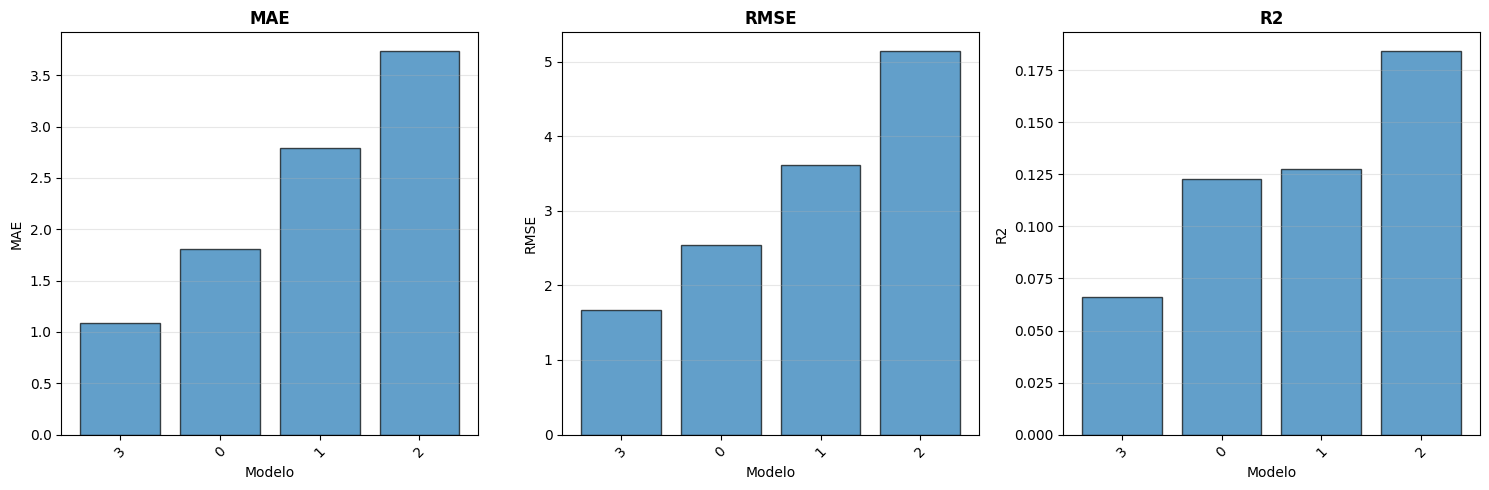


📊 Comparación entre productos:


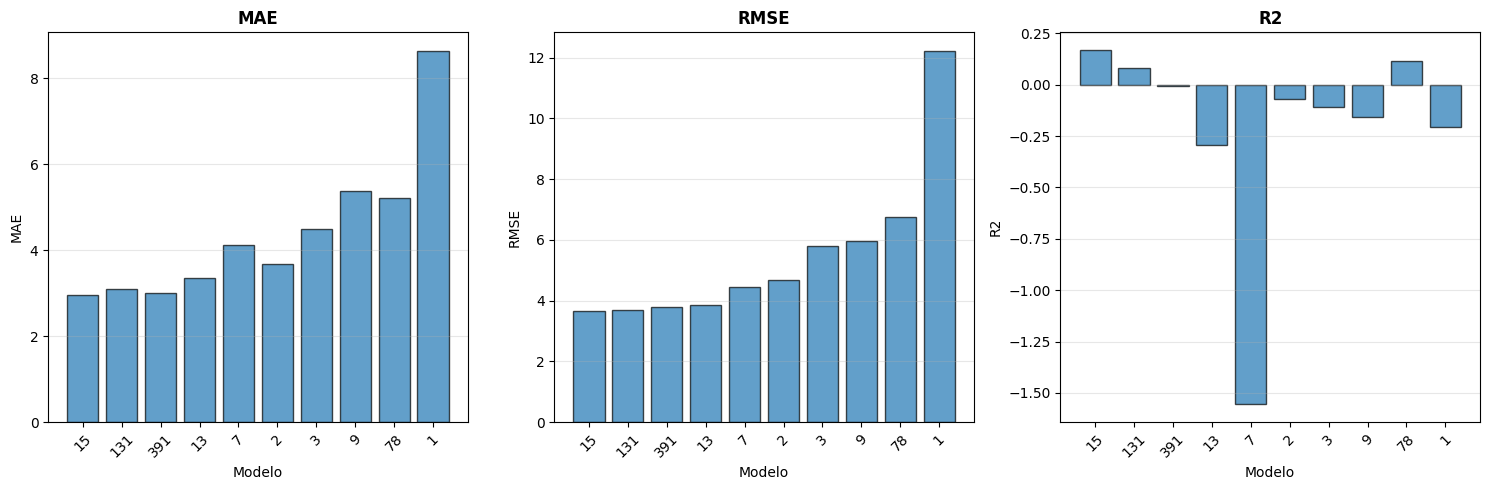


✅ ANÁLISIS COMPLETO FINALIZADO

📊 Total de modelos evaluados: 15
   - Modelos globales: 1
   - Modelos por cluster: 4
   - Modelos por producto: 10


In [10]:

# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Mostrar tabla completa de métricas
    print("\n📊 Resumen de todas las métricas:")
    resumen_metricas(todas_metricas)
    
    # Comparar métricas
    df_comparacion_final = comparar_metricas(todas_metricas, ordenar_por='RMSE')
    
    print("\n" + "="*100)
    print("📈 RANKING DE MODELOS POR RMSE")
    print("="*100)
    print(df_comparacion_final[['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)']].to_string(index=False))
    
    # Gráfico comparativo de TODOS los modelos
    print("\n📊 Generando gráficos comparativos...")
    grafico_comparacion_metricas(df_comparacion_final, metricas=['MAE', 'RMSE', 'R2'])
    
    # Análisis por categorías
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS")
    print("="*100)
    
    # Separar por tipo de modelo
    df_global = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Global')]
    df_clusters = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Cluster')]
    df_productos = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Producto')]
    
    print("\n🌍 MODELOS GLOBALES:")
    if len(df_global) > 0:
        print(df_global[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_global['RMSE'].mean():.2f}")
    
    print("\n🎯 MODELOS POR CLUSTER:")
    if len(df_clusters) > 0:
        print(df_clusters[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_clusters['RMSE'].mean():.2f}")
        print(f"   Mejor cluster: {df_clusters.iloc[0]['Algoritmo']} (RMSE: {df_clusters.iloc[0]['RMSE']:.2f})")
        print(f"   Peor cluster: {df_clusters.iloc[-1]['Algoritmo']} (RMSE: {df_clusters.iloc[-1]['RMSE']:.2f})")
    
    print("\n🛒 MODELOS POR PRODUCTO:")
    if len(df_productos) > 0:
        print(df_productos[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_productos['RMSE'].mean():.2f}")
        print(f"   Mejor producto: {df_productos.iloc[0]['Algoritmo']} (RMSE: {df_productos.iloc[0]['RMSE']:.2f})")
        print(f"   Peor producto: {df_productos.iloc[-1]['Algoritmo']} (RMSE: {df_productos.iloc[-1]['RMSE']:.2f})")
    
    # Mejor modelo general
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]
    
    print(f"\n🏆 {mejor_modelo['Algoritmo']}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    
    # Gráficos comparativos por categoría
    if len(df_clusters) > 1:
        print("\n📊 Comparación entre clusters:")
        grafico_comparacion_metricas(df_clusters, metricas=['MAE', 'RMSE', 'R2'])
    
    if len(df_productos) > 1:
        print("\n📊 Comparación entre productos:")
        grafico_comparacion_metricas(df_productos, metricas=['MAE', 'RMSE', 'R2'])
    
else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if 'Global' in m['Algoritmo']])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if 'Cluster' in m['Algoritmo']])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if 'Producto' in m['Algoritmo']])}")


In [11]:

# Salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_catboost.csv', index=False)
print("\nResultados guardados en 'datos/resultados_metricas_catboost.csv'")


Resultados guardados en 'datos/resultados_metricas_catboost.csv'


# CatBoost por Cluster

# CatBoost por top 10 productos de ventas

# Resumen final

# Salvar resultados